# 01 — Exploratory Data Analysis

**Project:** COM-480 — Global Energy Trade Dependencies & Commodity Flows  
**Data source:** UN Comtrade API (HS Chapter 27 — Mineral Fuels)  

---

## Objective

This notebook explores global energy trade patterns to extract insights that directly drive the visualization design.

Three core questions we aim to answer:

1. **How has global energy trade evolved over time?** → motivates a time-slider choropleth
2. **Which countries dominate and which are dependent?** → motivates country-level color encoding and drill-down
3. **What are the key bilateral corridors?** → motivates a flow/chord diagram

> **Note:** Data quality has already been assessed in `00_data_quality_assessment.ipynb`. This notebook focuses on insights, not data cleaning.

## 1. Setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 20)

FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Consistent colour palette
BLUE  = '#2563EB'
RED   = '#DC2626'
GREEN = '#16A34A'
GRAY  = '#6B7280'

## 2. Load Data & Quick Overview

In [3]:
df = pd.read_csv('../data/processed/energy_trade.csv', low_memory=False)
cs = pd.read_csv('../data/processed/country_summary.csv')   # pre-aggregated by country × year
ps = pd.read_csv('../data/processed/partner_summary.csv')   # pre-aggregated by reporter × partner × year

# Work primarily with bilateral rows (real countries, no World/Areas-nes aggregates)
bilateral = df[df['partner_iso3'].notna()].copy()

print(f'Full dataset        : {len(df):>10,} rows')
print(f'Bilateral subset    : {len(bilateral):>10,} rows  (partner_iso3 not null)')
print(f'country_summary     : {len(cs):>10,} rows')
print(f'partner_summary     : {len(ps):>10,} rows')
print(f'\nYear range : {df.year.min()} – {df.year.max()}')
print(f'Reporters  : {df.reporter.nunique()}')
print(f'Partners   : {df.partner.nunique()}')

Full dataset        :    393,777 rows
Bilateral subset    :    351,743 rows  (partner_iso3 not null)
country_summary     :      4,143 rows
partner_summary     :    279,879 rows

Year range : 2000 – 2023
Reporters  : 203
Partners   : 251


In [4]:
df[['year','reporter','reporter_iso3','partner','partner_iso3',
    'flow','trade_value_usd']].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,"393,777.00",NaN,NaN,NaN,"2,012.29",6.78,"2,000.00","2,007.00","2,013.00","2,018.00","2,023.00"
reporter,393777,203,France,7060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reporter_iso3,369320,181,FRA,7060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partner,393777,251,World,8084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
partner_iso3,351743,204,USA,6686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flow,393777,2,Import,197382,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trade_value_usd,"393,777.00",NaN,NaN,NaN,"496,367,512.24","5,969,440,455.89",0.00,"26,772.37","676,702.71","22,670,210.00","535,339,702,649.00"


> The dataset contains ~394k rows covering 24 years, 203 reporters, and 251 partners. Every row has a non-null `trade_value_usd` — the core metric for all visualizations.

---
## 3. Global Trade Evolution Over Time

How has the total reported volume of energy trade changed from 2000 to 2023?

In [5]:
# Use bilateral rows and split by flow to avoid double-counting World partner
yearly = (
    bilateral
    .groupby(['year', 'flow'])['trade_value_usd']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
yearly.columns.name = None
yearly['Total'] = yearly['Import'] + yearly['Export']
yearly[['Import','Export','Total']] = yearly[['Import','Export','Total']] / 1e12  # USD trillion

yearly.head()

,year,Export,Import,Total
0,2000,0.41,0.62,1.03
1,2001,0.39,0.57,0.96
2,2002,0.41,0.57,0.97
3,2003,0.50,0.72,1.22
4,2004,0.67,0.97,1.63


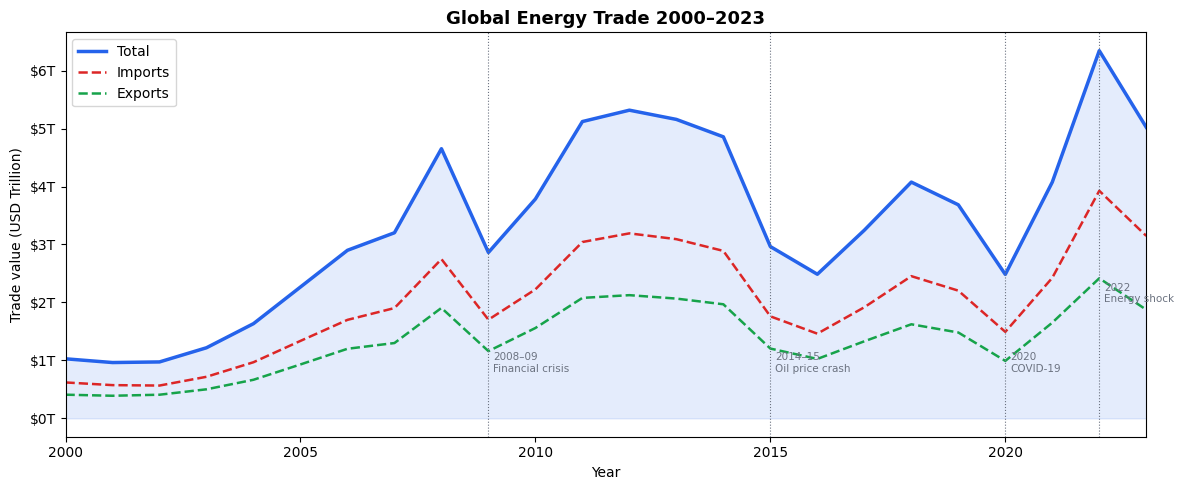

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(yearly['year'], yearly['Total'], alpha=0.12, color=BLUE)
ax.plot(yearly['year'], yearly['Total'], color=BLUE,  lw=2.5, label='Total')
ax.plot(yearly['year'], yearly['Import'], color=RED,   lw=1.8, ls='--', label='Imports')
ax.plot(yearly['year'], yearly['Export'], color=GREEN, lw=1.8, ls='--', label='Exports')

# Annotate key events
for yr, label, y_off in [
    (2009, '2008–09\nFinancial crisis', 0.8),
    (2015, '2014–15\nOil price crash',  0.8),
    (2020, '2020\nCOVID-19',            0.8),
    (2022, '2022\nEnergy shock',         2.0),
]:
    ax.axvline(yr, color=GRAY, lw=0.8, ls=':')
    ax.text(yr + 0.1, y_off, label, fontsize=7.5, color=GRAY)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}T'))
ax.set_xlabel('Year')
ax.set_ylabel('Trade value (USD Trillion)')
ax.set_title('Global Energy Trade 2000–2023', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim(2000, 2023)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_global_trade_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insights:**
> - Global energy trade **tripled between 2000 and 2014**, driven by surging oil prices and China's industrialisation.
> - Three sharp drops are visible: the **2008–09 financial crisis**, the **2014–16 oil price crash**, and the **2020 COVID-19** shock — all followed by strong recoveries.
> - 2022 shows a **historic peak**, driven by the energy shock following Russia's invasion of Ukraine, which restructured global fossil-fuel flows.
> - Imports and exports track each other closely (mirror trade), confirming data consistency.
>
> **Visualization implication:** The time-slider on the choropleth should span 2000–2023. Annotating these shocks on the slider could enrich storytelling.

---
## 4. Top Trading Countries

In [7]:
# Aggregate over all years from country_summary
cs_total = cs.groupby('country').agg(
    total_imports=('total_imports', 'sum'),
    total_exports=('total_exports', 'sum'),
).reset_index().assign(
    total_trade=lambda d: d['total_imports'] + d['total_exports']
).sort_values('total_trade', ascending=False)

top_importers = cs_total.nlargest(10, 'total_imports')
top_exporters = cs_total.nlargest(10, 'total_exports')

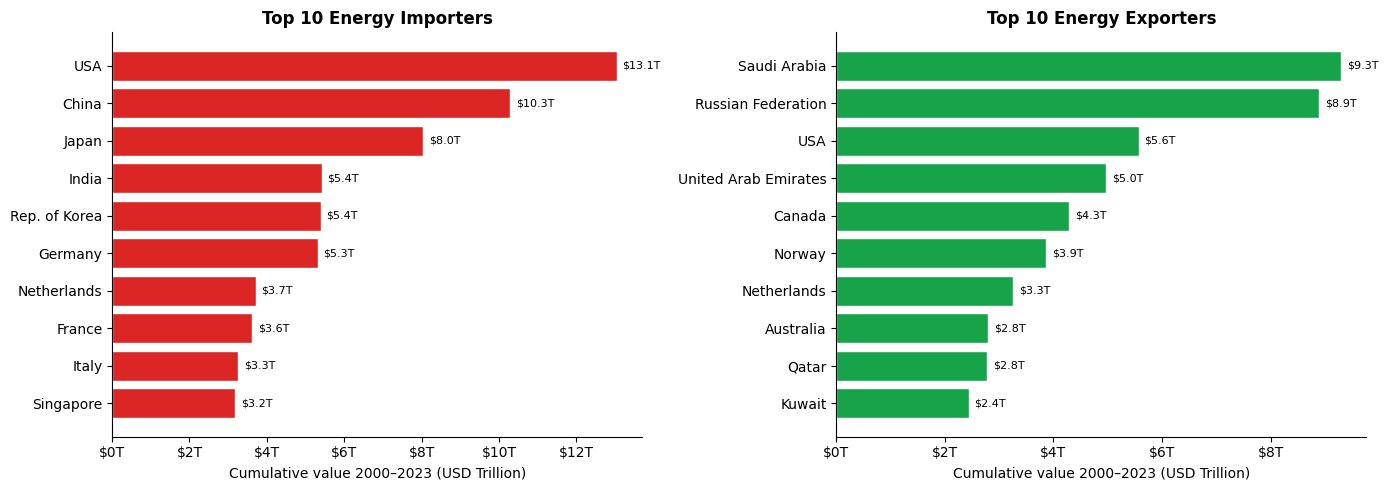

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def _bar(ax, data, col, color, title):
    vals = data[col].values / 1e12
    labels = data['country'].values
    bars = ax.barh(labels[::-1], vals[::-1], color=color, edgecolor='white')
    ax.bar_label(bars, labels=[f'${v:.1f}T' for v in vals[::-1]], padding=4, fontsize=8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Cumulative value 2000–2023 (USD Trillion)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}T'))
    ax.spines[['top','right']].set_visible(False)

_bar(axes[0], top_importers, 'total_imports', RED,   'Top 10 Energy Importers')
_bar(axes[1], top_exporters, 'total_exports', GREEN, 'Top 10 Energy Exporters')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_top_traders.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Countries appearing in both top-10 lists
both = set(top_importers['country']) & set(top_exporters['country'])
print('Countries in both top-10 importers AND exporters:', both)

Countries in both top-10 importers AND exporters: {'Netherlands', 'USA'}


> **Insights:**
> - **USA, China, Japan, Germany, South Korea** are the dominant importers — energy-intensive economies that rely heavily on external supply.
> - **Russian Federation, Saudi Arabia, UAE, Norway, Canada** dominate exports — fossil-fuel producers.
> - **USA, Netherlands, Belgium** appear in both lists — they are both consumers and major transit/re-export hubs, particularly for LNG and oil.
>
> **Visualization implication:** The choropleth color scale should be anchored on these extremes. The importer/exporter toggle helps users understand structural roles.

---
## 5. Trade Concentration — Measuring Dependency

A country that sources 80% of its energy imports from a single partner is highly vulnerable. We quantify this using the **top-1 partner share** and a simplified **Herfindahl-Hirschman Index (HHI)**.

In [10]:
# Aggregate bilateral imports over all years: reporter → partner
import_flows = (
    bilateral[bilateral['flow'] == 'Import']
    .groupby(['reporter', 'partner'])['trade_value_usd']
    .sum()
    .reset_index()
)

# Total imports per reporter
reporter_totals = import_flows.groupby('reporter')['trade_value_usd'].sum().rename('reporter_total')
import_flows = import_flows.join(reporter_totals, on='reporter')
import_flows['share'] = import_flows['trade_value_usd'] / import_flows['reporter_total']

# HHI = sum of squared shares per reporter
hhi = (
    import_flows
    .groupby('reporter')
    .apply(lambda g: (g['share'] ** 2).sum(), include_groups=False)
    .rename('hhi')
    .reset_index()
)

# Top-1 partner share per reporter
top1 = (
    import_flows
    .sort_values('share', ascending=False)
    .groupby('reporter')
    .first()
    .reset_index()
    .rename(columns={'partner': 'top_partner', 'share': 'top1_share'})
    [['reporter', 'top_partner', 'top1_share']]
)

concentration = top1.merge(hhi, on='reporter')

# Filter reporters with meaningful import volume (> $1B cumulative)
min_trade = reporter_totals[reporter_totals > 1e9].index
concentration = concentration[concentration['reporter'].isin(min_trade)]

print(f'Reporters analysed: {len(concentration)}')
print(concentration.sort_values('top1_share', ascending=False).head(10).to_string(index=False))

Reporters analysed: 179
          reporter          top_partner  top1_share  hhi
            Bhutan                India        0.99 0.98
State of Palestine               Israel        0.97 0.94
           Lesotho         South Africa        0.97 0.94
           Belarus   Russian Federation        0.96 0.93
       Cayman Isds                  USA        0.96 0.92
              Iraq United Arab Emirates        0.96 0.92
           Liberia        Côte d'Ivoire        0.95 0.90
             Nepal                India        0.92 0.85
          Botswana         South Africa        0.89 0.80
           Bahrain         Saudi Arabia        0.89 0.79


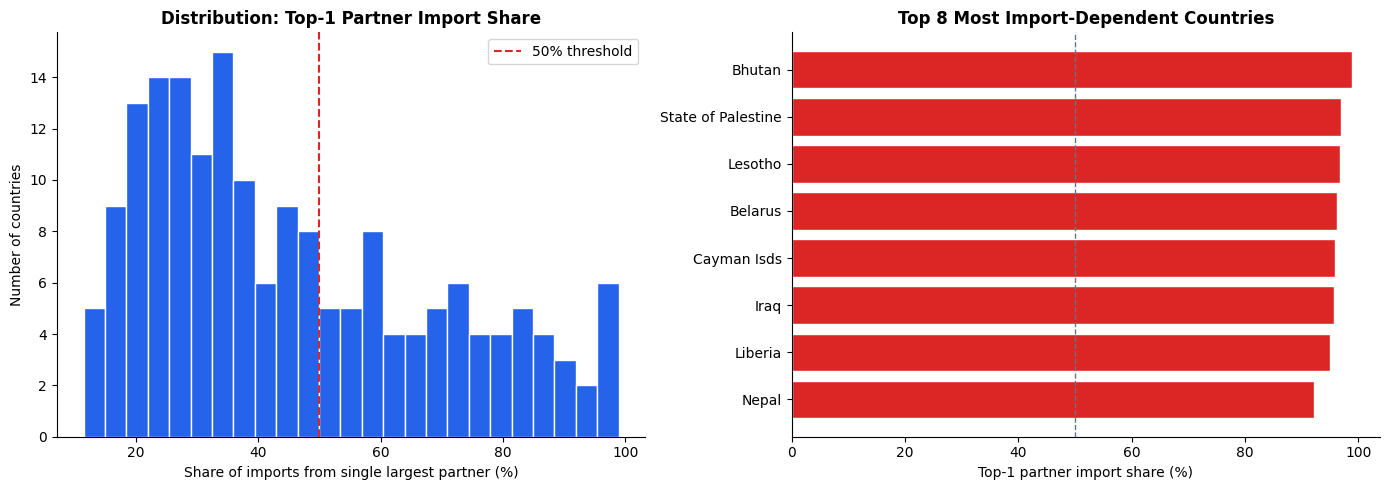

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of top-1 share
axes[0].hist(concentration['top1_share'] * 100, bins=25, color=BLUE, edgecolor='white')
axes[0].axvline(50, color=RED, ls='--', lw=1.5, label='50% threshold')
axes[0].set_title('Distribution: Top-1 Partner Import Share', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Share of imports from single largest partner (%)')
axes[0].set_ylabel('Number of countries')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Most concentrated vs most diversified
n = 8
top_dep = concentration.nlargest(n, 'top1_share')
top_div = concentration.nsmallest(n, 'hhi')

axes[1].barh(top_dep['reporter'][::-1], top_dep['top1_share'][::-1] * 100,
             color=RED, edgecolor='white', label='Most dependent')
axes[1].axvline(50, color=GRAY, ls='--', lw=1)
axes[1].set_title(f'Top {n} Most Import-Dependent Countries', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Top-1 partner import share (%)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_trade_concentration.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Most diversified importers (lowest HHI)
print('Most diversified importers (lowest HHI):')
print(concentration.nsmallest(10, 'hhi')[['reporter','top_partner','top1_share','hhi']].to_string(index=False))

Most diversified importers (lowest HHI):
       reporter        top_partner  top1_share  hhi
          Spain            Algeria        0.11 0.06
          China       Saudi Arabia        0.13 0.06
           Togo        Netherlands        0.14 0.06
         France            Belgium        0.15 0.07
      Singapore           Malaysia        0.12 0.07
          India       Saudi Arabia        0.15 0.07
       Portugal              Spain        0.20 0.08
          Italy Russian Federation        0.18 0.08
Other Asia, nes       Saudi Arabia        0.19 0.08
  Rep. of Korea       Saudi Arabia        0.20 0.08


> **Insights:**
> - A large share of countries source **more than 50% of their energy imports from a single partner**, revealing structural dependency.
> - Highly dependent countries are often smaller economies with geographic or historical ties to one major supplier.
> - Large economies (USA, Germany, China, Japan) tend to be the most **diversified** — they spread imports across many partners.
>
> **Visualization implication:** The dependency score (HHI or top-1 share) is a powerful secondary color dimension. A toggle between "trade volume" and "dependency score" would let users explore vulnerability vs. scale.

---
## 6. Bilateral Trade Corridors

Which country pairs generate the largest bilateral energy flows?

In [13]:
# Top bilateral pairs (all years, both flows, bilateral subset)
top_pairs = (
    bilateral[bilateral['flow'] == 'Export']   # use exports to avoid double-counting
    .groupby(['reporter', 'partner'])['trade_value_usd']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
top_pairs['pair'] = top_pairs['reporter'] + ' → ' + top_pairs['partner']
top_pairs['value_tn'] = top_pairs['trade_value_usd'] / 1e12
top_pairs

,reporter,partner,trade_value_usd,pair,value_tn
0,Canada,USA,"1,987,201,854,956.72",Canada → USA,1.99
1,Russian Federation,Netherlands,"680,364,478,380.92",Russian Federation → Netherlands,0.68
2,Norway,United Kingdom,"599,602,703,244.73",Norway → United Kingdom,0.60
3,Netherlands,Germany,"527,880,916,277.12",Netherlands → Germany,0.53
4,Mexico,USA,"476,779,374,210.00",Mexico → USA,0.48
5,USA,Mexico,"462,417,482,470.00",USA → Mexico,0.46
6,USA,Canada,"393,030,342,993.00",USA → Canada,0.39
7,Angola,China,"376,207,909,605.08",Angola → China,0.38
8,Russian Federation,China,"374,462,775,340.28",Russian Federation → China,0.37
9,Qatar,Japan,"369,850,610,222.52",Qatar → Japan,0.37


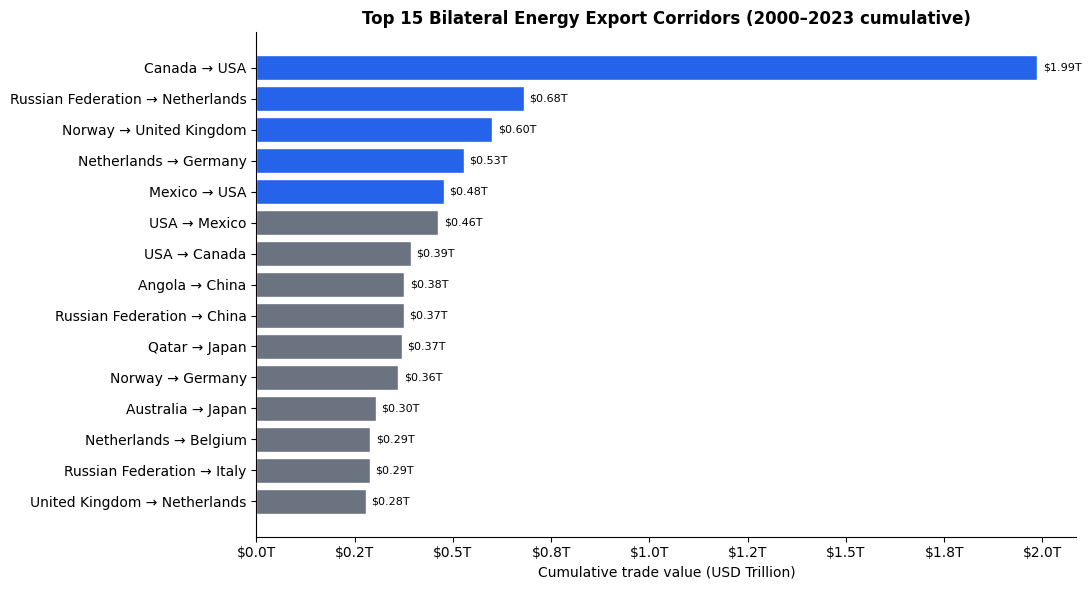

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = [BLUE if i < 5 else GRAY for i in range(len(top_pairs))]
bars = ax.barh(top_pairs['pair'][::-1], top_pairs['value_tn'][::-1], color=colors[::-1], edgecolor='white')
ax.bar_label(bars, labels=[f'${v:.2f}T' for v in top_pairs['value_tn'][::-1]], padding=4, fontsize=8)
ax.set_title('Top 15 Bilateral Energy Export Corridors (2000–2023 cumulative)', fontsize=12, fontweight='bold')
ax.set_xlabel('Cumulative trade value (USD Trillion)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}T'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_bilateral_corridors.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insights:**
> - The **Canada–USA** corridor is the world's largest energy trade flow by value, reflecting deep North American energy integration.
> - **Russia → Netherlands/Germany** corridors were major until 2022, after which they collapsed — visible in year-level analysis.
> - **Saudi Arabia / UAE → Japan** highlight Asia's dependence on Gulf oil.
> - **Netherlands and Belgium** repeatedly appear as both origin and destination, confirming their role as European energy hubs.
>
> **Visualization implication:** A chord or Sankey diagram for the top N corridors would be a powerful companion to the choropleth. Click-on-country → show top partners is the core interaction.

---
## 7. Imports vs Exports Balance — Structural Roles of Countries

In [15]:
# Aggregate balance over all years
balance = cs.groupby('country').agg(
    total_imports=('total_imports', 'sum'),
    total_exports=('total_exports', 'sum'),
).reset_index().assign(
    balance=lambda d: d['total_exports'] - d['total_imports'],
    total_trade=lambda d: d['total_imports'] + d['total_exports']
).dropna().set_index('country')

# Filter to meaningful traders only
balance = balance[balance['total_trade'] > 5e10]

net_exporters = balance.nlargest(10, 'balance')
net_importers = balance.nsmallest(10, 'balance')

print('Top net exporters (USD bn):')
print((net_exporters[['balance']] / 1e9).round(0).to_string())
print()
print('Top net importers (USD bn):')
print((net_importers[['balance']] / 1e9).round(0).to_string())

Top net exporters (USD bn):
                      balance
country                      
Saudi Arabia         9,175.00
Russian Federation   8,796.00
United Arab Emirates 4,505.00
Norway               3,669.00
Qatar                2,768.00
Canada               2,738.00
Kuwait               2,438.00
Nigeria              2,129.00
Iran                 1,694.00
Australia            1,639.00

Top net importers (USD bn):
                balance
country                
China         -8,893.00
Japan         -7,564.00
USA           -7,480.00
Germany       -3,952.00
Rep. of Korea -3,829.00
India         -3,692.00
France        -2,740.00
Italy         -2,473.00
Spain         -1,724.00
Türkiye       -1,559.00


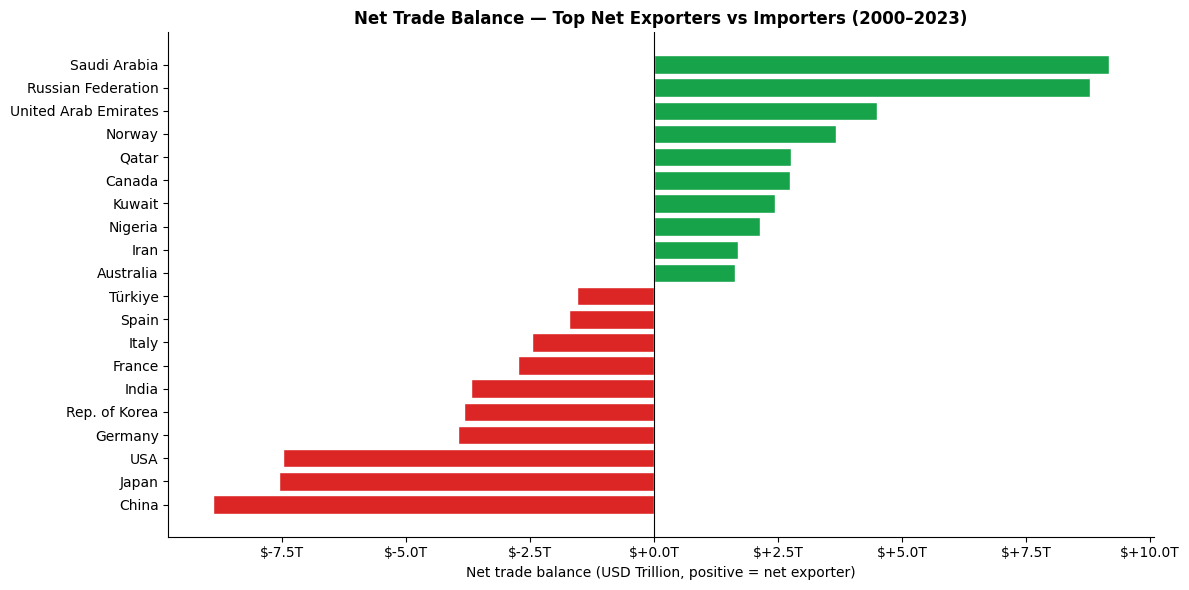

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

combined = pd.concat([net_exporters, net_importers]).sort_values('balance')
colors = [GREEN if b > 0 else RED for b in combined['balance']]
bars = ax.barh(combined.index, combined['balance'] / 1e12, color=colors, edgecolor='white')

ax.axvline(0, color='black', lw=0.8)
ax.set_title('Net Trade Balance — Top Net Exporters vs Importers (2000–2023)', fontsize=12, fontweight='bold')
ax.set_xlabel('Net trade balance (USD Trillion, positive = net exporter)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+.1f}T'))
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_trade_balance.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insights:**
> - **Russia, Saudi Arabia, Norway, UAE, Kuwait** are the world's structural net energy exporters — their economies depend on fossil-fuel export revenue.
> - **USA, China, Japan, Germany, India** are the largest net importers — energy-intensive manufacturing and consumption economies.
> - The USA's position is notable: it is simultaneously one of the largest importers *and* exporters, reflecting its role as both a producer (shale revolution) and consumer.
>
> **Visualization implication:** Net balance (green = exporter, red = importer) is a natural diverging color scale for the choropleth. This immediately communicates structural roles.

---
## 8. Commodity Coverage — HS Chapter 27 in Context

In [17]:
print(f'Unique product codes in processed data: {df["product_code"].nunique()}')
print(f'Product code(s): {df["product_code"].unique()}')
print(f'Product description: {df["product"].iloc[0][:80]}...')

Unique product codes in processed data: 1
Product code(s): [27]
Product description: Mineral fuels, mineral oils and products of their distillation; bituminous subst...


In [18]:
# HS 27 sub-heading breakdown (documented, not in this processed file)
hs27_subcodes = pd.DataFrame([
    ('2701', 'Coal',              'Solid fossil fuels'),
    ('2709', 'Crude petroleum',   'Liquid fossil fuels — raw'),
    ('2710', 'Petroleum products','Refined oil, diesel, gasoline, kerosene'),
    ('2711', 'Natural gas / LNG', 'Gas in natural or liquefied form'),
    ('2712', 'Petroleum jelly / waxes', 'Paraffin, mineral waxes'),
    ('2713', 'Petroleum coke / bitumen', 'Residues from oil refining'),
    ('2716', 'Electrical energy', 'Cross-border power trade'),
], columns=['HS Code', 'Commodity', 'Description'])

print('HS Chapter 27 sub-headings covered by this dataset:')
print(hs27_subcodes.to_string(index=False))

HS Chapter 27 sub-headings covered by this dataset:
HS Code                Commodity                             Description
   2701                     Coal                      Solid fossil fuels
   2709          Crude petroleum               Liquid fossil fuels — raw
   2710       Petroleum products Refined oil, diesel, gasoline, kerosene
   2711        Natural gas / LNG        Gas in natural or liquefied form
   2712  Petroleum jelly / waxes                 Paraffin, mineral waxes
   2713 Petroleum coke / bitumen              Residues from oil refining
   2716        Electrical energy                Cross-border power trade


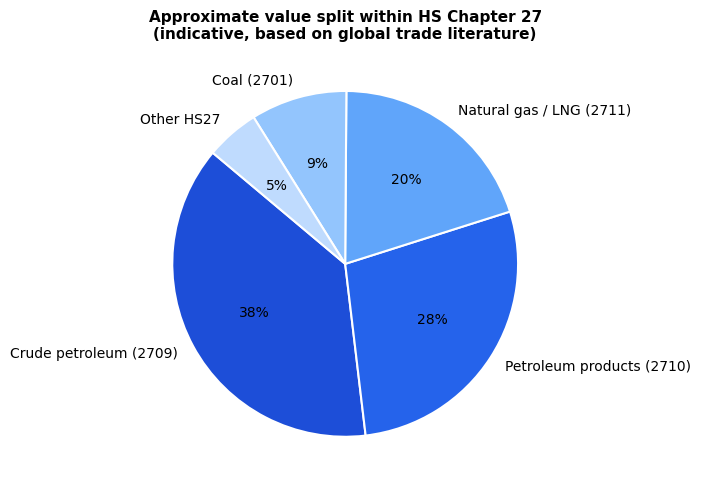

In [19]:
# Approximate value split using global trade shares from IEA/UN literature
# (indicative only — our processed file uses chapter-level aggregates)
approx_shares = pd.DataFrame([
    ('Crude petroleum (2709)',     38),
    ('Petroleum products (2710)',  28),
    ('Natural gas / LNG (2711)',   20),
    ('Coal (2701)',                 9),
    ('Other HS27',                  5),
], columns=['Commodity', 'Approx. % of value'])

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    approx_shares['Approx. % of value'],
    labels=approx_shares['Commodity'],
    autopct='%1.0f%%',
    startangle=140,
    colors=['#1D4ED8','#2563EB','#60A5FA','#93C5FD','#BFDBFE'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('Approximate value split within HS Chapter 27\n(indicative, based on global trade literature)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_commodity_split.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insights:**
> - The processed dataset uses **chapter-level aggregates** (HS 27 total), which is the correct grain for cross-country comparison on a world map — it avoids double-counting that would arise from summing sub-headings.
> - The dataset covers **all major fossil fuels**: crude oil, refined products, natural gas, coal, and electrical energy.
> - Crude petroleum and refined products together account for ~65% of the total value — crude oil prices dominate the time-series dynamics seen in Section 3.
>
> **Visualization implication:** If a future version needs commodity-level breakdown, the downloader (`src/download_comtrade.py`) can be extended to request 4-digit HS codes, which would add a commodity-filter to the dashboard.

---
## 9. Geographic Distribution — Static Choropleth Preview

This previews the main visualization. We show total energy imports per country across all years.

In [20]:
# Aggregate imports per country using reporter_iso3
import_map = (
    df[df['flow'] == 'Import']
    .dropna(subset=['reporter_iso3'])
    .groupby(['reporter_iso3', 'reporter'])['trade_value_usd']
    .sum()
    .reset_index()
)
import_map['log_value'] = np.log10(import_map['trade_value_usd'].clip(lower=1))
import_map.head()

,reporter_iso3,reporter,trade_value_usd,log_value
0,ABW,Aruba,"2,227,750,382.53",9.35
1,AFG,Afghanistan,"31,031,209,774.04",10.49
2,AGO,Angola,"75,707,931,647.61",10.88
3,AIA,Anguilla,"255,578,129.00",8.41
4,ALB,Albania,"27,765,395,114.11",10.44


In [21]:
fig = px.choropleth(
    import_map,
    locations='reporter_iso3',
    color='log_value',
    hover_name='reporter',
    hover_data={'trade_value_usd': ':,.0f', 'log_value': False},
    color_continuous_scale='Blues',
    range_color=[import_map['log_value'].quantile(0.05),
                 import_map['log_value'].quantile(0.99)],
    labels={'log_value': 'log₁₀(Import USD)'},
    title='Cumulative Energy Imports by Country, 2000–2023 (log scale)'
)
fig.update_layout(
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    coloraxis_colorbar=dict(title='log₁₀(USD)')
)
fig.show()

In [22]:
# Also preview: net balance map
balance_map = (
    df.dropna(subset=['reporter_iso3'])
    .groupby(['reporter_iso3', 'reporter', 'flow'])['trade_value_usd']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
balance_map['net_balance'] = balance_map.get('Export', 0) - balance_map.get('Import', 0)
balance_map['net_bn'] = balance_map['net_balance'] / 1e9

fig2 = px.choropleth(
    balance_map,
    locations='reporter_iso3',
    color='net_bn',
    hover_name='reporter',
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=0,
    range_color=[-500, 500],
    labels={'net_bn': 'Net balance (USD bn)'},
    title='Net Energy Trade Balance by Country, 2000–2023 (green = net exporter)'
)
fig2.update_layout(margin={'r': 0, 't': 50, 'l': 0, 'b': 0})
fig2.show()

> **Insights:**
> - The **import volume** map clearly shows the concentration in North America, Europe, and East Asia — the world's major energy consumers.
> - The **net balance** map cleanly separates the world into green (exporters: Russia, Gulf, West Africa, Norway, Canada) and red (importers: Asia, Europe, USA).
> - Countries that appear gray have missing ISO3 codes — the patch described in `00_data_quality_assessment.ipynb` will fill these.
>
> **Visualization implication:** This confirms that the choropleth design works. The Dash app in `app.py` renders this dynamically with a year slider and flow-type dropdown.

---
## 10. Key Insights for Visualization

### Summary of findings

| # | Finding | Visualization implication |
|---|---|---|
| 1 | Global energy trade tripled 2000–2014, with clear shocks in 2009, 2015, 2020, 2022 | Year slider — annotate key events |
| 2 | Trade is dominated by ~10–15 countries on each side (importers/exporters) | Choropleth color scale anchored on these extremes |
| 3 | Many countries source >50% of imports from a single partner | Secondary encoding: dependency score toggle |
| 4 | Clear bilateral corridors: Canada–USA, Russia–EU, Gulf–Japan | Country click → top partners panel |
| 5 | Net balance cleanly separates producer vs. consumer economies | Diverging (red/green) balance view |
| 6 | All data is HS Chapter 27 (energy); sub-code extension is possible | Dashboard ready for future commodity filter |
| 7 | 181 countries have valid ISO3 — sufficient for a meaningful world map | Choropleth is viable; 15-entry patch improves coverage |

### Confirmed design decisions

- **Primary view:** Choropleth colored by import/export/net-balance volume, year slider 2000–2023
- **Secondary view:** Side panel showing top bilateral partners when a country is clicked
- **Color scales:** Blues for imports, Greens for exports, Red–Green diverging for net balance
- **Log scale:** Necessary for trade value coloring due to the 5-order-of-magnitude spread
- **Dependency dimension:** HHI or top-1 share as an optional color toggle